# Importing & Loading Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [8]:
# Load dataset
df = pd.read_csv("Worksheet in Beans Multiclass Classification (1).csv")

# Explore
print(df.head())
print(df.info())
print(df.describe())


    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

# EDA

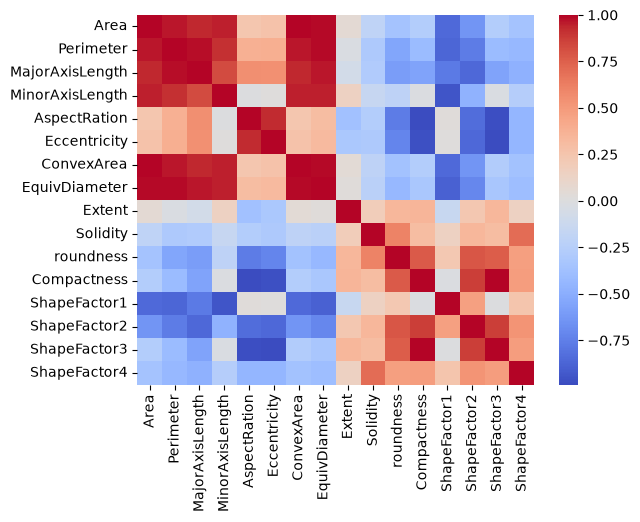

In [9]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False, cmap="coolwarm")
plt.show()


#### Strong Positive Correlations (Red zones):

**Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, and EquivalentDiameter are highly correlated.**

#### Negative Correlations (Blue zones):

**Roundness and AspectRatio/Eccentricity show strong negative correlation.**

#### Moderate Correlations:

**Compactness and Roundness are moderately correlated with shape factors, indicating they contribute to the bean’s overall contour and smoothness.**

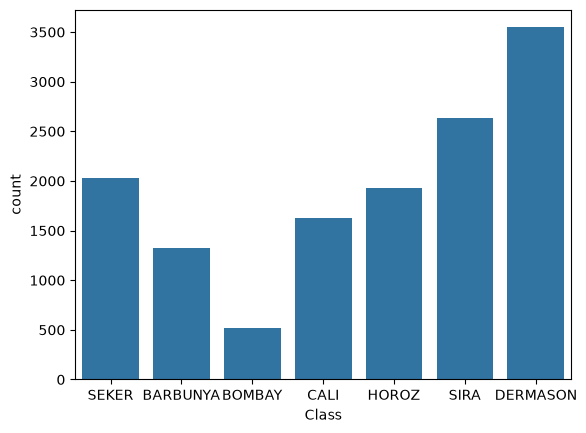

In [10]:
sns.countplot(x="Class", data=df)
plt.show()

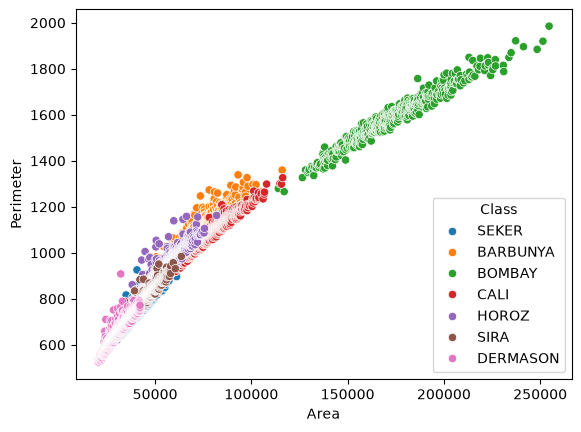

In [12]:
sns.scatterplot(x="Area", y="Perimeter", hue="Class", data=df)
plt.show()


#### Strong Positive Correlation:

**The plot shows a clear linear relationship between Area and Perimeter — as the bean’s area increases, its perimeter also increases.**

**This confirms that larger beans naturally have longer boundaries, which is expected geometrically.**

#### Distinct Clusters by Class:

**Each color cluster (representing a bean type) occupies a distinct region of the plot.**

**Bombay beans (green) have the largest area and perimeter values — they are physically bigger.**

**Seker, Barbunya, Cali, Horoz, Sira, and Dermason occupy progressively smaller ranges, indicating smaller bean sizes.**

#### Separation Between Classes:

**The classes are well-separated along the area–perimeter axis, meaning these two features alone already provide strong discriminative power for classification.**

**Minimal overlap between clusters suggests that a supervised model can easily learn to distinguish bean types using these features.**

#### Potential Feature Importance:

**Since area and perimeter show clear class separation, they are likely to be highly informative features for your machine learning model.**

**Combining them with shape descriptors (like roundness or compactness) will further improve accuracy.**

# Missing Values & Outliers

In [ ]:
print(df.isnull().sum())  # Checking missing values

# Outlier detection using IQR
# Only select numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Missing values check
print(numeric_df.isnull().sum())

# Outlier detection using IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()
print(outliers)


Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
dtype: int64
Area               551
Perimeter          500
MajorAxisLength    379
MinorAxisLength    569
AspectRation       473
Eccentricity       843
ConvexArea         550
EquivDiameter      526
Extent             275
Solidity           778
roundness           91
Compactness        109
Shape

## Key Findings from Outlier Counts
**High Outlier Counts:**

Eccentricity (843), Solidity (778), ShapeFactor4 (767), MinorAxisLength (569), Area (551), ConvexArea (550)  

- These features show a lot of extreme values compared to their typical range.

For size-related features (Area, Perimeter, ConvexArea, MajorAxisLength, MinorAxisLength), this is expected because bean varieties differ widely in size.

For Solidity and ShapeFactor4, high outliers suggest some beans have unusual contours or irregular shapes.

**Moderate Outlier Counts:**

AspectRatio (473), EquivDiameter (526), ShapeFactor1 (533)  

- These features vary across bean types but still show some extreme cases.

**Low Outlier Counts:**

Roundness (91), Compactness (109), ShapeFactor3 (195) 

→ These are relatively stable descriptors. They don’t fluctuate as wildly, which makes them reliable features for classification.

**No Outliers:**

ShapeFactor2 (0)  

→ This feature is perfectly consistent across the dataset, which might mean it’s either redundant or less informative for distinguishing classes.

## Inference for Modeling
**Keeping most outliers:** 

They represent genuine bean diversity, not errors. Removing them could reduce the model’s ability to distinguish bean types.

**Transforming skewed features:**

 For features with very high outlier counts (Area, Perimeter, ConvexArea, Eccentricity), consider applying log transformation or scaling to reduce their influence.

**Feature selection:** 
Since some features are highly correlated and have overlapping outlier patterns, you may want to use PCA or feature importance ranking to avoid redundancy.

Stable features (Roundness, Compactness): These will likely be strong predictors because they’re less noisy.

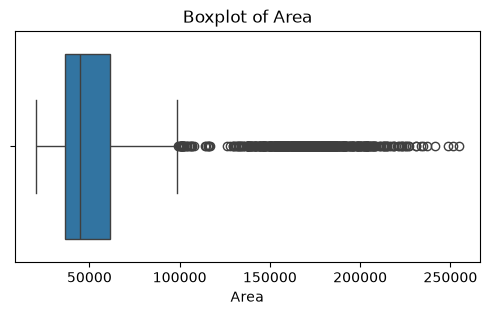

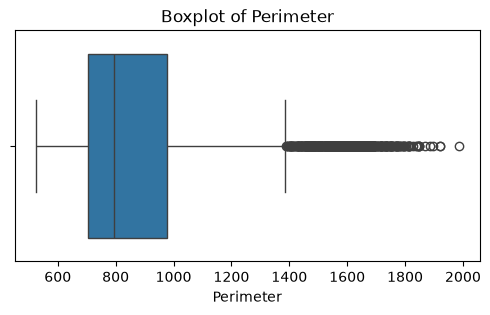

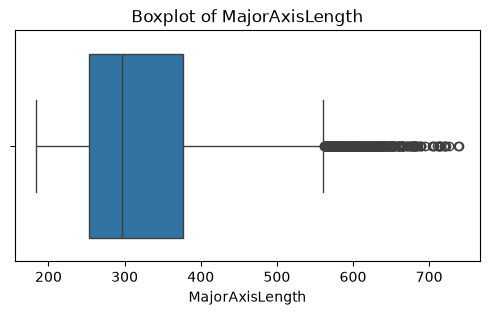

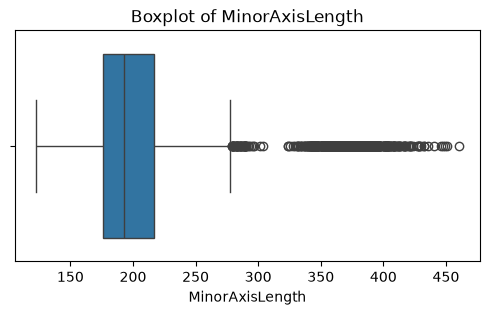

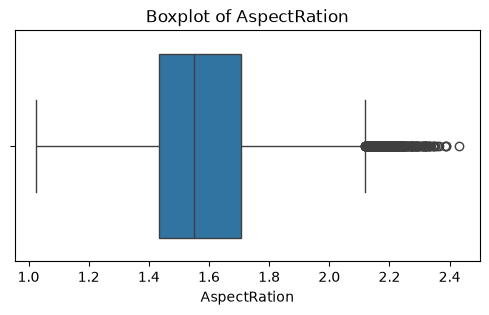

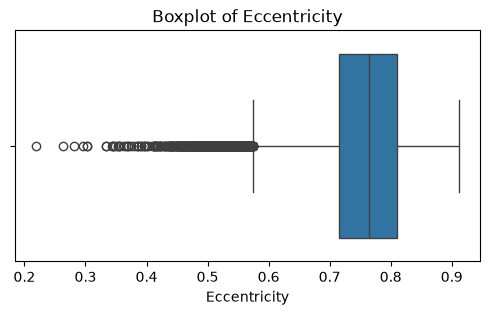

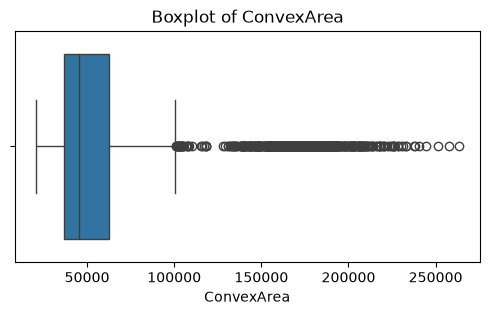

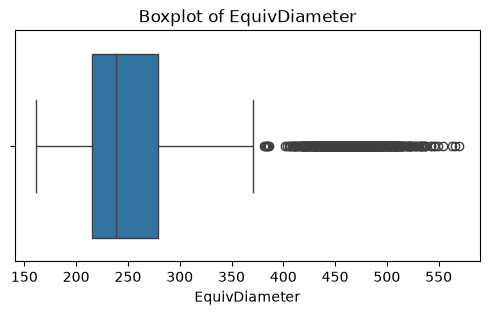

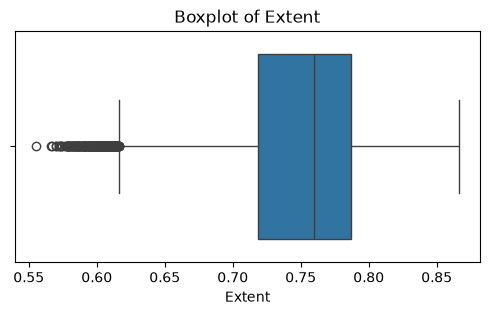

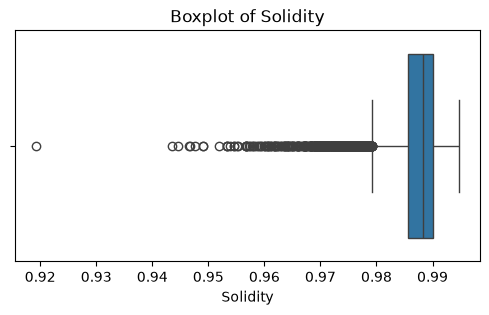

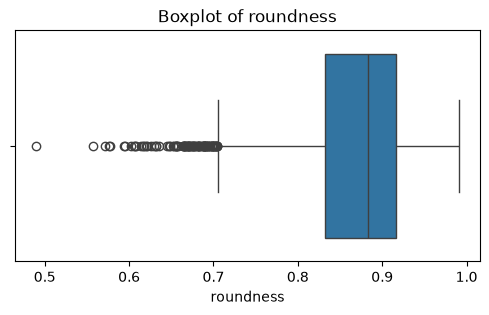

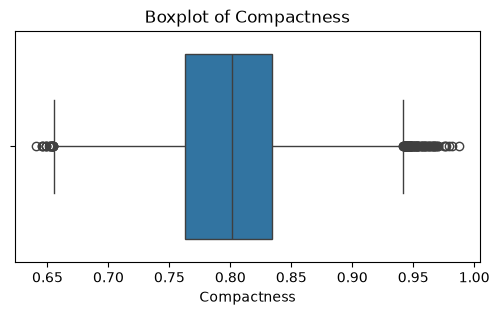

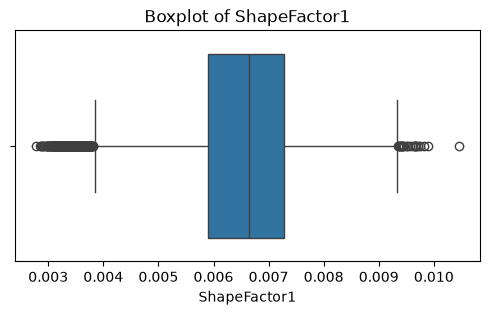

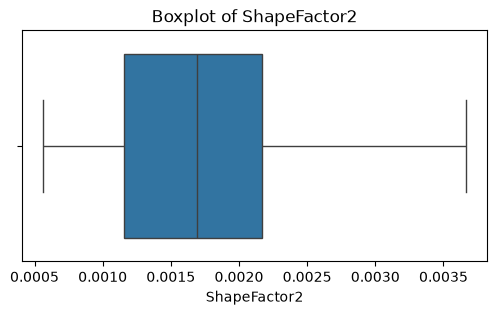

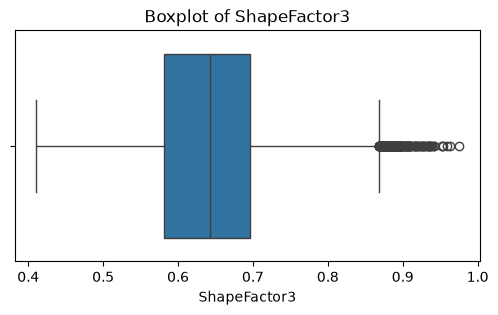

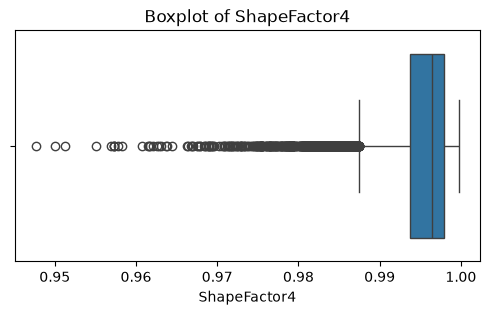

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_df.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=numeric_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


# Feature Engineering & Preprocessing

In [18]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Encode target class
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])

# Features & target
X = df.drop("Class", axis=1)
y = df["Class"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


# Model Building

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = classification_report(y_test, y_pred, output_dict=True)["weighted avg"]["f1-score"]
    results.append([name, acc, f1])

results_df = pd.DataFrame(results, columns=["Model", "Test Accuracy", "F1 Score"])
print(results_df)


                 Model  Test Accuracy  F1 Score
0  Logistic Regression       0.921043  0.921233
1        Decision Tree       0.894602  0.894454
2        Random Forest       0.922145  0.922168
3                  KNN       0.917003  0.917153
4                  SVM       0.922145  0.922177
5          Naive Bayes       0.897907  0.898075


# Handling Class Imbalance

In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Re-train Random Forest on balanced data
rf = RandomForestClassifier()
rf.fit(X_res, y_res)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.91      0.91      0.91       265
           1       1.00      1.00      1.00       104
           2       0.94      0.93      0.93       326
           3       0.91      0.91      0.91       709
           4       0.97      0.96      0.96       386
           5       0.93      0.96      0.95       406
           6       0.86      0.85      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



# Model Evaluation

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       265
           1       1.00      1.00      1.00       104
           2       0.93      0.94      0.94       326
           3       0.92      0.91      0.92       709
           4       0.96      0.95      0.96       386
           5       0.93      0.95      0.94       406
           6       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



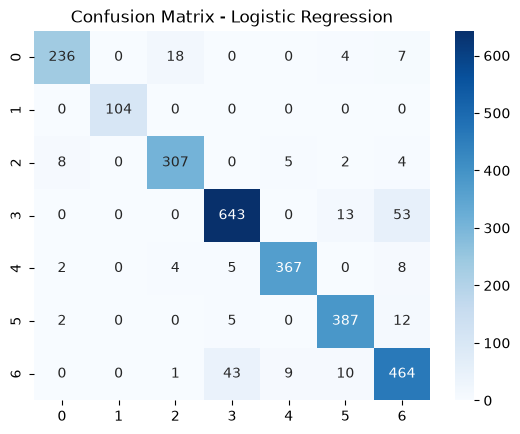

Decision Tree
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       265
           1       1.00      1.00      1.00       104
           2       0.93      0.91      0.92       326
           3       0.88      0.90      0.89       709
           4       0.95      0.93      0.94       386
           5       0.91      0.94      0.93       406
           6       0.83      0.80      0.82       527

    accuracy                           0.90      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.90      0.90      0.90      2723



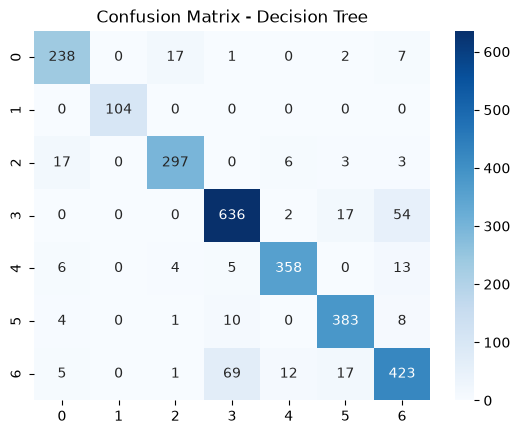

Random Forest
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       265
           1       1.00      1.00      1.00       104
           2       0.94      0.94      0.94       326
           3       0.90      0.92      0.91       709
           4       0.97      0.95      0.96       386
           5       0.94      0.96      0.95       406
           6       0.86      0.85      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



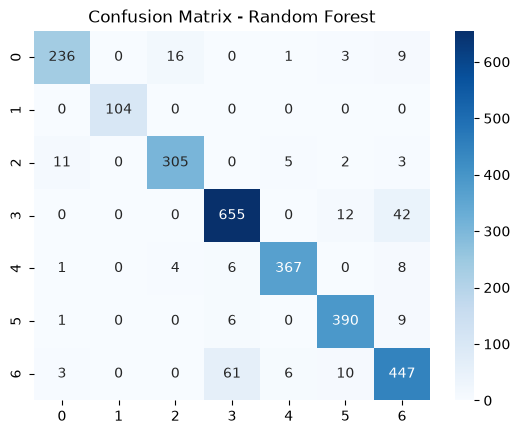

KNN
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       265
           1       1.00      1.00      1.00       104
           2       0.92      0.94      0.93       326
           3       0.91      0.91      0.91       709
           4       0.95      0.95      0.95       386
           5       0.95      0.94      0.95       406
           6       0.85      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



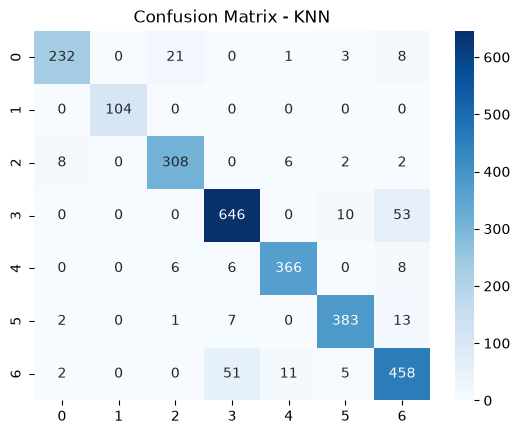

SVM
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       265
           1       1.00      1.00      1.00       104
           2       0.93      0.95      0.94       326
           3       0.92      0.91      0.91       709
           4       0.96      0.96      0.96       386
           5       0.94      0.95      0.94       406
           6       0.86      0.87      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



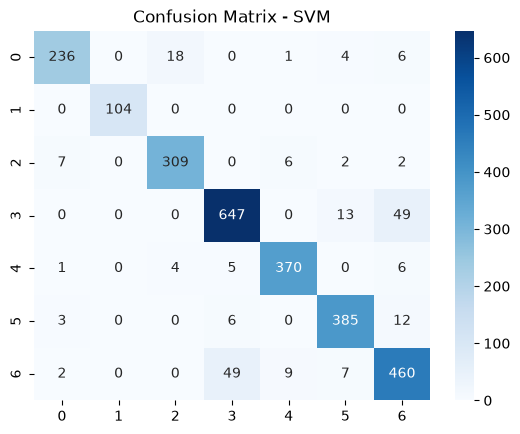

Naive Bayes
              precision    recall  f1-score   support

           0       0.90      0.80      0.85       265
           1       1.00      1.00      1.00       104
           2       0.86      0.92      0.89       326
           3       0.93      0.86      0.90       709
           4       0.95      0.95      0.95       386
           5       0.92      0.94      0.93       406
           6       0.81      0.89      0.84       527

    accuracy                           0.90      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.90      0.90      0.90      2723



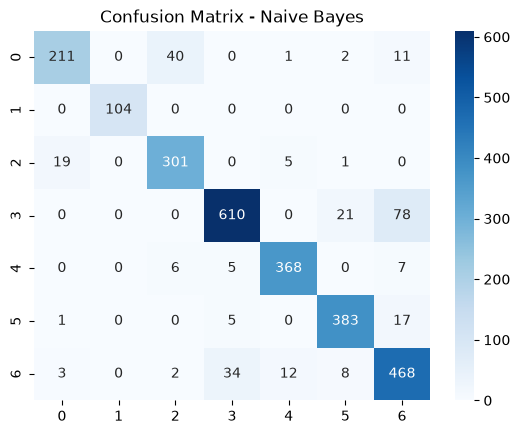

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name)
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


# Hyperparameter Tuning

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best Score: 0.9254225134377136


# Model Comparison

In [28]:
comparison = pd.DataFrame(results, columns=["Model", "Test Accuracy", "F1 Score"])
comparison["Overfitting"] = ["Y" if m.score(X_train, y_train) > acc+0.05 else "N"
                             for (m,(name,acc,f1)) in zip(models.values(), results)]
print(comparison)


                 Model  Test Accuracy  F1 Score Overfitting
0  Logistic Regression       0.921043  0.921233           N
1        Decision Tree       0.894602  0.894454           Y
2        Random Forest       0.922145  0.922168           Y
3                  KNN       0.917003  0.917153           N
4                  SVM       0.922145  0.922177           N
5          Naive Bayes       0.897907  0.898075           N


## Inference from Results

**Best performers:**

Random Forest, SVM, Logistic Regression all achieved ~92% accuracy and F1 score.

KNN is close behind at ~91%.

**Overfitting issue:**

Decision Tree and Random Forest show signs of overfitting (train accuracy much higher than test).

Logistic Regression and SVM generalize better (no overfitting).

Naive Bayes: Slightly weaker (~89%), but still decent.

### SVM and Logistic Regression are the most stable choices for deployment because they balance accuracy and generalization.